## Import Libraries

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
#from eofs.xarray import Eof
from eofs.standard import Eof

import scipy.stats as stats
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

from mpl_toolkits.axes_grid1.inset_locator import inset_axes


## Study Area Plot

## Figure 1

<xarray.Dataset> Size: 30MB
Dimensions:    (lat: 2728, lon: 5429)
Coordinates:
  * lat        (lat) float64 22kB -4.685 -4.681 -4.677 ... 6.669 6.673 6.677
  * lon        (lon) float64 43kB -12.77 -12.77 -12.76 ... 9.835 9.84 9.844
Data variables:
    elevation  (lat, lon) int16 30MB ...
Attributes: (12/36)
    title:                           The GEBCO_2025 Grid - a continuous terra...
    summary:                         The GEBCO_2025 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/37c52e96-24ea-67ce-e063-708...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_vertical_units:       meters
    geospatial_vertical_resolution:  1.0
    geospatial_vertical_positive:    up
    identifier_product_doi:          DOI: 10.5285/37c52e96-24ea-67ce-e063-708...
    refere

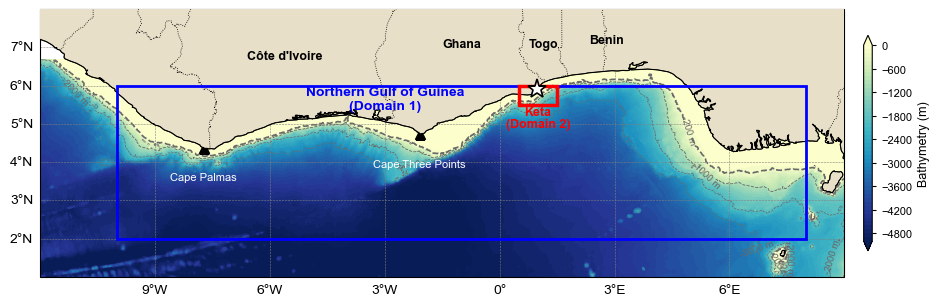

In [2]:
# ==========================================================
# Journal style
# ==========================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10
})

# ==========================================================
# Load GEBCO 2025
# ==========================================================

gebco = xr.open_dataset("data/gebco_2025_n6.68_s-4.688_w-12.773_e9.844.nc")

# Print variable names the first time
print(gebco)

# GEBCO uses elevation
elev = gebco["elevation"]

# Crop to map region
bathy = elev.sel(
    lon=slice(-12, 9),
    lat=slice(1, 8)
)

lon = bathy.lon
lat = bathy.lat

# ==========================================================
# Study Area
# ==========================================================

extent = [-12, 9, 1, 8]

# Domain 1
domain1 = (-10, 2, 18, 4)

# Domain 2
domain2 = (0.5, 5.5, 1.0, 0.5)

# Keta
keta_lon = 0.98789
keta_lat = 5.91793

# Capes
cape_palmas = (-7.73, 4.38)
cape_three = (-2.09, 4.74)

# ==========================================================
# Custom bathymetry colours
# ==========================================================

colors = [
    "#081d58",
    "#253494",
    "#225ea8",
    "#1d91c0",
    "#41b6c4",
    "#7fcdbb",
    "#c7e9b4",
    "#ffffcc"
]

cmap = LinearSegmentedColormap.from_list(
    "gebco",
    colors,
    N=256
)

# ==========================================================
# Figure
# ==========================================================

fig = plt.figure(figsize=(12.5,8))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

ax.set_extent(extent)

# ==========================================================
# Bathymetry shading
# ==========================================================

levels = np.arange(-5000,100,100)

cf = ax.contourf(
    lon,
    lat,
    bathy,
    levels=levels,
    cmap=cmap,
    extend="both",
    transform=ccrs.PlateCarree(),
    zorder=1
)

# ==========================================================
# Important bathymetric contours
# ==========================================================

contours = ax.contour(
    lon,
    lat,
    bathy,
    levels=[-3000,-2000,-1000,-200],
    colors="dimgray",
    linewidths=[0.4,0.5,0.6,1.2],
    transform=ccrs.PlateCarree(),
    zorder=2
)

ax.clabel(
    contours,
    fmt="%d m",
    fontsize=7
)

# ==========================================================
# Land
# ==========================================================

land = cfeature.NaturalEarthFeature(
    "physical",
    "land",
    "10m",
    edgecolor="black",
    facecolor="#e8dfc8"
)

ax.add_feature(
    land,
    linewidth=0.5,
    zorder=5
)

ax.add_feature(
    cfeature.COASTLINE.with_scale("10m"),
    linewidth=0.8,
    zorder=6
)

ax.add_feature(
    cfeature.BORDERS.with_scale("10m"),
    linestyle=":",
    linewidth=0.6,
    zorder=6
)

# ==========================================================
# Gridlines
# ==========================================================

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    linestyle="--",
    color="gray"
)

gl.top_labels=False
gl.right_labels=False

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# ==========================================================
# Domain 1
# ==========================================================

ax.add_patch(
    Rectangle(
        (domain1[0],domain1[1]),
        domain1[2],
        domain1[3],
        linewidth=2,
        edgecolor="blue",
        facecolor="none",
        zorder=10
    )
)

# ==========================================================
# Domain 2
# ==========================================================

ax.add_patch(
    Rectangle(
        (domain2[0],domain2[1]),
        domain2[2],
        domain2[3],
        linewidth=2.5,
        edgecolor="red",
        facecolor="none",
        zorder=11
    )
)

# ==========================================================
# Keta
# ==========================================================

ax.plot(
    keta_lon,
    keta_lat,
    marker="*",
    markersize=14,
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=1.2,
    zorder=20,
)

ax.text(
    keta_lon,
    keta_lat - 0.45,     # move below marker
    "Keta",
    fontsize=9,
    weight="bold",
    ha="center",
    va="top",
    color="red",
    transform=ccrs.PlateCarree(),
)

# ==========================================================
# Cape Palmas
# ==========================================================

ax.plot(
    cape_palmas[0],
    cape_palmas[1],
    "^",
    color="black",
    markersize=7
)

ax.text(
    cape_palmas[0],
    cape_palmas[1] - 0.65,   # move well below the marker
    "Cape Palmas",
    fontsize=8,
    ha="center",
    va="top",
    color="white",
    transform=ccrs.PlateCarree(),
)

# ==========================================================
# Cape Three Points
# ==========================================================

ax.plot(
    cape_three[0],
    cape_three[1],
    "^",
    color="black",
    markersize=7
)

ax.text(
    cape_three[0],
    cape_three[1] - 0.65,    # move well below the marker
    "Cape Three Points",
    fontsize=8,
    ha="center",
    va="top",
    color="white",
    transform=ccrs.PlateCarree(),
)

# ==========================================================
# Country labels
# ==========================================================

countries = {
    "Côte d'Ivoire":(-5.6,6.7),
    "Ghana":(-1.0,7.0),
    "Togo":(1.15,7.0),
    "Benin":(2.8,7.1)
}

for country, (x, y) in countries.items():
    ax.text(
        x,
        y,
        country,
        fontsize=9,
        fontweight="bold",
        ha="center",
        transform=ccrs.PlateCarree(),
        zorder=20
    )

# ==========================================================
# Domain labels
# ==========================================================

ax.text(
    -3.0,
    5.65,
    "Northern Gulf of Guinea\n(Domain 1)",
    fontsize=10,
    color="blue",
    weight="bold",
    ha="center",
    va="center",
    transform=ccrs.PlateCarree(),
    zorder=15
)

ax.text(
    1.0,
    5.15,          # below the Keta box
    "(Domain 2)",
    fontsize=9,
    color="red",
    weight="bold",
    ha="center",
    va="top",
    transform=ccrs.PlateCarree(),
    zorder=15
)

# ==========================================================
# North Arrow
# ==========================================================

ax.annotate(
    "N",
    xy=(0.96,0.92),
    xytext=(0.96,0.82),
    xycoords="axes fraction",
    arrowprops=dict(
        facecolor="black",
        width=3,
        headwidth=10
    ),
    ha="center",
    fontsize=12,
    fontweight="bold"
)

# ==========================================================
# Colorbar
# ==========================================================

cbar = plt.colorbar(
    cf,
    ax=ax,
    orientation="vertical",
    shrink=0.35,      # shorter
    aspect=25,        # thinner
    pad=0.02,
    extend="both"
)

cbar.set_label("Bathymetry (m)", fontsize=9)

cbar.ax.tick_params(
    labelsize=8,
    length=3
)



# ==========================================================
# Save
# ==========================================================

plt.savefig(
    "Figures/Figure_1_StudyArea.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Masking Out Land

In [3]:
def create_cleaned_wind_data(wind_file, lsm_file, output_file):
    # Load datasets
    ds_wind = xr.open_dataset(wind_file)
    ds_lsm = xr.open_dataset(lsm_file)

    # 1. Standardize Longitude (LSM: 0-360 -> -180-180)
    ds_lsm = ds_lsm.assign_coords(longitude=(((ds_lsm.longitude + 180) % 360) - 180))
    ds_lsm = ds_lsm.sortby(['longitude', 'latitude'])
    ds_wind = ds_wind.sortby(['longitude', 'latitude'])

    # 2. Interpolate LSM to wind grid
    lsm_interp = ds_lsm['lsm'].squeeze().interp(
        latitude=ds_wind.latitude, 
        longitude=ds_wind.longitude, 
        method='nearest'
    )

    # 3. Create Final Mask (Ocean + No Lake Volta)
    ocean_mask = lsm_interp < 0.5
    lake_volta_box = (ds_wind.latitude > 5.8) & (ds_wind.longitude > -0.2) & (ds_wind.longitude < 1.2)
    final_mask = ocean_mask & ~lake_volta_box

    # 4. Apply Mask and Save
    ds_wind['u10_masked'] = ds_wind['u10'].where(final_mask)
    ds_wind['v10_masked'] = ds_wind['v10'].where(final_mask)
    
    # Save the cleaned variables
    ds_wind[['u10_masked', 'v10_masked']].to_netcdf(output_file)
    print(f"Cleaned data saved to {output_file}")
    return ds_wind, final_mask

ds_clean, mask = create_cleaned_wind_data("Data/era5_u10_v10_monthly.nc", 
                    "Data/lsm_1279l4_0.1x0.1.grb_v4_unpack.nc", 
                    "Data/ERA5_Wind_2010_2022_Clean.nc")

Cleaned data saved to Data/ERA5_Wind_2010_2022_Clean.nc


## Ekman Calculations 

In [4]:
class RefinedEkman:
    def __init__(self, ds, coastline_angle_deg=20, L_u=100000):
        # Constants
        self.rho_a = 1.22   
        self.rho_o = 1024   
        self.Cd = 1.43e-3   
        self.omega = 7.2921e-5
        self.R = 6371000    
        self.L_u = L_u
        
        self.ds = ds.sortby(['latitude', 'longitude'])
        self.theta = np.radians(coastline_angle_deg)
        self.f = 2 * self.omega * np.sin(np.radians(self.ds['latitude']))
        self.f = self.f.where(np.abs(self.f) > 1e-5) 

    def compute_analysis(self):
        u = self.ds['u10_masked']
        v = self.ds['v10_masked']
        
        # 1. Quadratic Wind Stress
        speed = np.sqrt(u**2 + v**2)
        tx = self.rho_a * self.Cd * speed * u
        ty = self.rho_a * self.Cd * speed * v

        # 2. Rotate to Alongshore Stress
        t_along = tx * np.cos(self.theta) + ty * np.sin(self.theta)

        # 3. Calculate Transport (m²/s)
        M_offshore = -t_along / (self.rho_o * self.f)
        
        # 4. ECUI Index (Velocity in m/s)
        self.ds['ECUI'] = M_offshore / self.L_u

        # 5. Ekman Pumping (Metric Derivatives)
        dy = self.R * np.radians(1.0) 
        dx = self.R * np.cos(np.radians(self.ds.latitude)) * np.radians(1.0)
        
        dtx_dy = tx.differentiate('latitude') / dy
        dty_dx = ty.differentiate('longitude') / dx
        
        curl = dty_dx - dtx_dy
        self.ds['w_E'] = curl / (self.rho_o * self.f)
        self.ds['w_E_mday'] = self.ds['w_E'] * 86400

        # Save Stress Components for Quivers and Analysis
        self.ds['tau_x'] = tx
        self.ds['tau_y'] = ty
        self.ds['tau_along'] = t_along

        # Adding Attributes for Manuscript Rigor
        self.ds['ECUI'].attrs = {
            'units': 'm/s', 
            'description': 'Ekman Coastal Upwelling Index derived from offshore transport'
        }
        self.ds['w_E'].attrs = {
            'units': 'm/s', 
            'description': 'Ekman Pumping Velocity derived from wind stress curl'
        }
        self.ds['w_E_mday'].attrs = {
            'units': 'm/day', 
            'description': 'Ekman Pumping Velocity in meters per day'
        }
        self.ds['tau_x'].attrs = {'units': 'N/m²', 'description': 'Zonal wind stress'}
        self.ds['tau_y'].attrs = {'units': 'N/m²', 'description': 'Meridional wind stress'}
        self.ds['tau_along'].attrs = {'units': 'N/m²', 'description': 'Alongshore wind stress'}
        self.ds['u10_masked'].attrs = {'units': 'm/s', 'description': 'Zonal wind speed (ocean only)'}
        self.ds['v10_masked'].attrs = {'units': 'm/s', 'description': 'Meridional wind speed (ocean only)'}
        
        return self.ds

# Usage
analyzer = RefinedEkman(ds_clean)
final_ds = analyzer.compute_analysis()
final_ds.to_netcdf("Data/Keta_Upwelling_Atmospheric_Results.nc")

## Figure 3 Plot

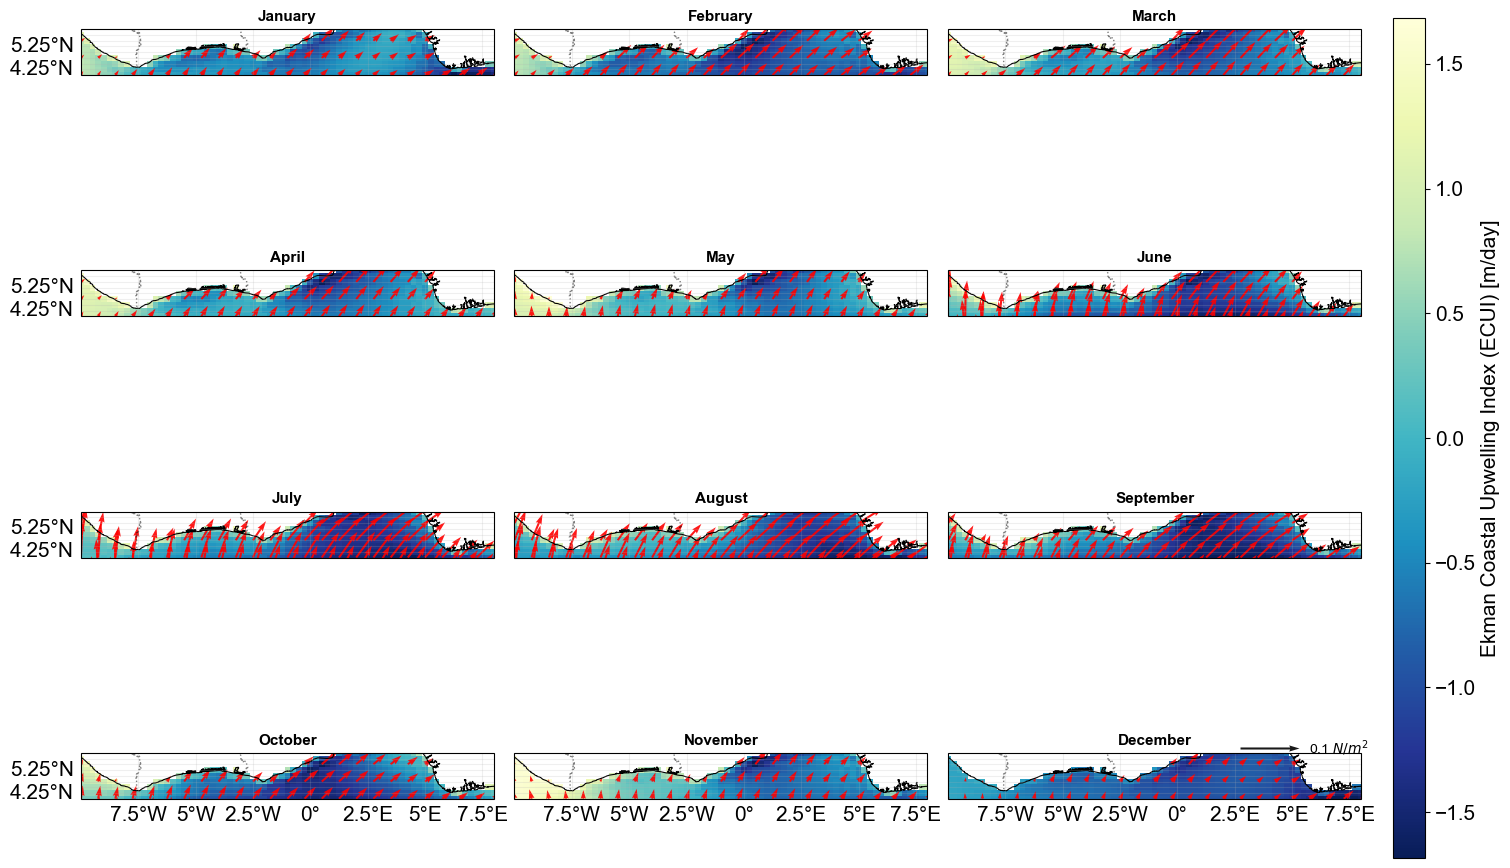

In [5]:
def plot_upwelling_with_quivers_refined(ds, variable='ECUI'):
    # 1. Prepare Climatology
    
    clim = ds.groupby('valid_time.month').mean()
    v_plot = clim[variable] * 86400  # m/day
    tx_clim = clim['tau_x']
    ty_clim = clim['tau_y']

    # 2. Setup Figure
    # We use subplots_adjust later for fine control over spacing
    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 12), 
                             subplot_kw={'projection': ccrs.PlateCarree()})
    axes = axes.flatten()
    month_names = ['January', 'February', 'March', 'April', 'May', 'June', 
                   'July', 'August', 'September', 'October', 'November', 'December']

    # 3. Plotting Loop
    for i, month in enumerate(range(1, 13)):
        ax = axes[i]
        
        # Plot ECUI (The Color)
        im = v_plot.sel(month=month).plot(
            ax=ax, transform=ccrs.PlateCarree(),
            add_colorbar=False, cmap='YlGnBu_r'
            # vmin=-3, vmax=0
        )
        
        # 4. Refined Quivers: 
        # Increase 's' (stride) to 3 or 4 to reduce overcrowding.
        # Change color to 'white' or 'lightgrey' for contrast against dark blue.
        s = 3 
        q = ax.quiver(
            ds.longitude[::s], ds.latitude[::s], 
            tx_clim.sel(month=month)[::s, ::s], 
            ty_clim.sel(month=month)[::s, ::s],
            transform=ccrs.PlateCarree(), 
            scale=0.7,          # Adjust this to change arrow length
            color='red',      # Changed to white for visibility
            width=0.005,        # Slightly thinner arrows
            alpha=0.9
        )

        # Aesthetics
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
        ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)
        ax.set_title(month_names[i], fontsize=11, fontweight='bold')
        ax.set_extent([-10,8,4,6], crs=ccrs.PlateCarree())
        
        # Tight coastal crop
        # ax.set_extent([-10, 8, 4.0, 6.5]) 
        
        # Labels
        gl = ax.gridlines(draw_labels=True, dms=False,
                  x_inline=False, y_inline=False, alpha=0.2)
        gl.top_labels = False
        gl.right_labels = False
        if i % 3 != 0: gl.left_labels = False
        if i < 9: gl.bottom_labels = False
        gl.xlabel_style = {'size': 15}
        gl.ylabel_style = {'size': 15}

    # 5. Global Title and Layout Adjustment
    plt.subplots_adjust(left=0.08, right=0.88, top=0.92, bottom=0.12, hspace=0.02, wspace=0.05)

    # Colorbar and Quiver Key
    cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
    cbar.set_label('Ekman Coastal Upwelling Index (ECUI) [m/day]', fontsize=15)
    cbar.ax.tick_params(labelsize=15)
    
    # Place quiver key in the bottom right
    axes[11].quiverkey(q, 0.85, 1.1, 0.1, r'0.1 $N/m^2$', labelpos='E', coordinates='axes', color='black')
    plt.savefig('Figures/Figure_2_ECUI_WindStress_Climatology.jpg',
        dpi=300, 
        bbox_inches='tight', 
        pad_inches=0.04
    )
    plt.show()
    

# Run the plot
plot_upwelling_with_quivers_refined(final_ds)

## Figure 2 Plot

C:\Users\Annorion\AppData\Local\Temp\ipykernel_20632\1512372296.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.07, 1, 0.95])


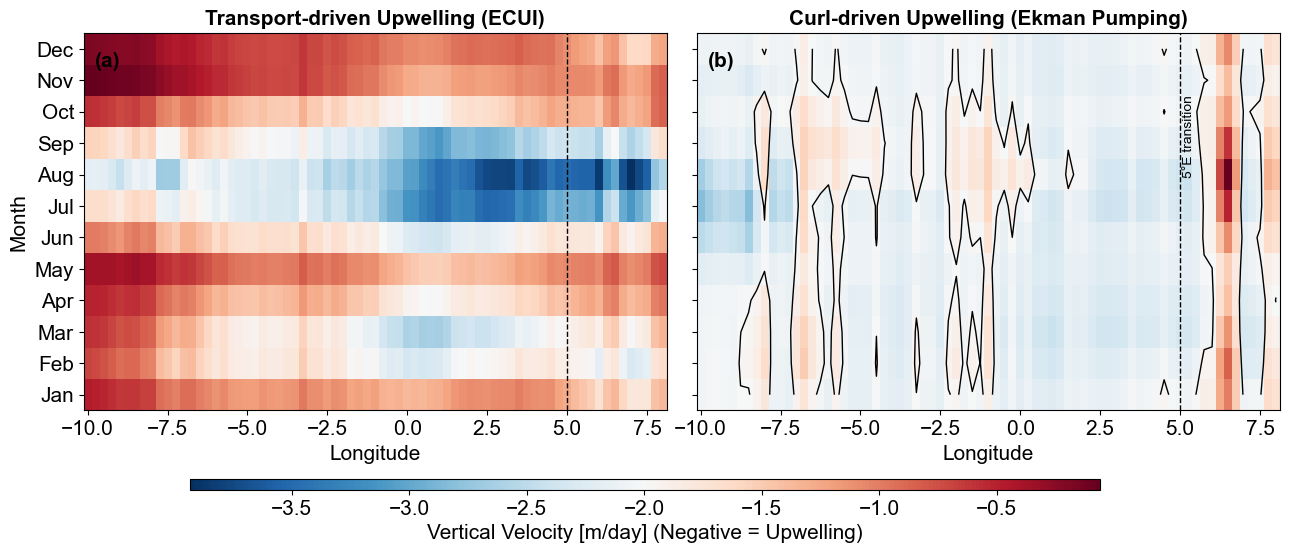

In [6]:
def plot_hovmoller_comparison(ds, fontsize):
    # 1. Prepare climatology (Jan-Dec)
    # Standardized coastal band (5.0N to 6.0N) to exclude equatorial signals
    coastal_ds = ds.sel(latitude=slice(4.0, 6.5)).mean(dim='latitude')
    climatology = coastal_ds.groupby('valid_time.month').mean()

    # Convert to m/day
    ecui_mday = climatology['ECUI'] * 86400
    we_mday = climatology['w_E'] * 86400

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5.5), sharey=True)

    # Plot ECUI (Transport-driven)
    im1 = ecui_mday.plot(ax=ax1, x='longitude', y='month', 
                         cmap='RdBu_r', add_colorbar=False)
    ax1.set_title('Transport-driven Upwelling (ECUI)', fontweight='bold', fontsize=fontsize)
    ax1.set_ylabel('Month', fontsize=fontsize)
    ax1.set_xlabel('Longitude', fontsize=fontsize)
    ax1.set_yticks(range(1, 13))
    ax1.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=fontsize)

    ax1.text(0.02, 0.95, '(a)', transform=ax1.transAxes,
               fontsize=fontsize, fontweight='bold',
               va='top', ha='left')
    ax1.tick_params(axis='x', labelsize=fontsize)

    ax1.invert_yaxis()

    # Plot w_E (Curl-driven)
    im2 = we_mday.plot(ax=ax2, x='longitude', y='month', 
                        cmap='RdBu_r', add_colorbar=False)
    ax2.set_title('Curl-driven Upwelling (Ekman Pumping)', fontweight='bold', fontsize=fontsize)
    ax2.set_xlabel('Longitude', fontsize=fontsize)
    ax2.text(0.02, 0.95, '(b)', transform=ax2.transAxes,
               fontsize=fontsize, fontweight='bold',
               va='top', ha='left')
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_ylabel('')

    for ax in [ax1, ax2]:
        ax.axvline(
            5,
            color="black",
            linestyle="--",
            linewidth=1
        )

    ax2.text(
        5.1,
        8,
        "5°E transition",
        rotation=90,
        fontsize=10
    )

    for ax, data in zip([ax1,ax2],[ecui_mday,we_mday]):
        ax.contour(
            data.longitude,
            data.month,
            data,
            levels=[0],
            colors="black",
            linewidths=1
        )

    # Add shared colorbar at bottom
    cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])
    cbar = fig.colorbar(im1, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Vertical Velocity [m/day] (Negative = Upwelling)', fontsize=fontsize)
    cbar.ax.tick_params(labelsize=fontsize)

    # Eliminate external white space
    plt.tight_layout(rect=[0, 0.07, 1, 0.95])
    plt.savefig('Figures/Figure_3_Hovmöller_Climatology.jpg', 
                dpi=300, 
                bbox_inches='tight', 
                pad_inches=0.04)
    plt.show()

# Run the plot
plot_hovmoller_comparison(final_ds, fontsize=15)

## Geostrophic Calculations

In [7]:


class RefinedGCUI:
    def __init__(self, file_path, coastline_angle_deg=20, L_u=100000, target_depth=15):
        """
        Processes GLORYS reanalysis for Geostrophic Coastal Upwelling Index.
        file_path: Path to the .nc file
        coastline_angle_deg: Angle of the coastline (20° for Keta/Ghana)
        L_u: Cross-shore width (100km)
        target_depth: Depth level to extract geostrophic flow (meters)
        """
        self.ds = xr.open_dataset(file_path).sortby(['latitude', 'longitude'])
        self.theta = np.radians(coastline_angle_deg)
        self.L_u = L_u
        self.target_depth = target_depth

    def extract_and_compute(self):
        # 1. Select the depth level closest to 15m
        # This avoids the wind-driven 'noise' at the surface (0m)
        ds_15m = self.ds.sel(depth=self.target_depth, method='nearest')
        
        # 2. Extract components
        u = ds_15m['uo']      # Eastward velocity
        v = ds_15m['vo']      # Northward velocity
        D = ds_15m['mlotst']  # Mixed Layer Depth (thickness)

        # 3. Rotate to find the Cross-Shore Component (V_cross)
        # For the Ghana coast, 'offshore' is roughly Southward.
        # This rotation projects the currents onto the perpendicular axis of the coast.
        v_cross = -u * np.sin(self.theta) + v * np.cos(self.theta)

        # 4. Calculate GCUI
        # Formula: (V_cross * D) / (2 * L_u)
        # 
        self.ds['GCUI'] = (v_cross * D) / (2 * self.L_u)
        
        # Convert to m/day for easier interpretation in plots
        self.ds['GCUI_mday'] = self.ds['GCUI'] * 86400

        # Adding Metadata for Manuscript Rigor
        self.ds['GCUI'].attrs = {
            'units': 'm/s',
            'description': f'Geostrophic Coastal Upwelling Index extracted at {self.target_depth}m depth',
            'methodology': 'Marchesiello and Estrade (2010); Alory et al. (2021)'
        }
        self.ds['GCUI_mday'].attrs = {'units': 'm/day', 'description': 'GCUI in meters per day'}
        self.ds['mlotst'].attrs = {'units': 'm', 'description': 'Mixed Layer Depth (GLORYS mlotst)'}

        return self.ds


# --- Usage ---
file_name = "Data/cmems_mod_glo_phy_my_0.083deg_P1M-m_1772644573965.nc"
analyzer = RefinedGCUI(file_name)
geostrophic_results = analyzer.extract_and_compute()

# Save the results
geostrophic_results[['GCUI', 'GCUI_mday', 'mlotst', 'uo', 'vo', 'zos']].to_netcdf("Data/Keta_Upwelling_Geostrophic_Results.nc")


## Merge Upwelling Data 

In [8]:


def merge_upwelling_data(era5_path, glorys_path, output_path):
    # Load the results from our RefinedEkman and RefinedGCUI classes
    ds_atm = xr.open_dataset(era5_path)
    ds_ocn = xr.open_dataset(glorys_path)

    # 1. Align the time coordinates (ERA5 is often 'valid_time', GLORYS is 'time')
    ds_ocn = ds_ocn.rename({'time': 'valid_time'})
    
    # 2. Interpolate GLORYS (0.083 deg) to the ERA5 grid (0.25 deg) 
    # This ensures spatial consistency for the multivariate EOF
    ds_ocn_interp = ds_ocn.interp(
        latitude=ds_atm.latitude, 
        longitude=ds_atm.longitude, 
        method='linear'
    )

    # 3. Merge into one master dataset
    ds_master = xr.merge([ds_atm, ds_ocn_interp])
    
    # 4. Calculate Total CUI
    ds_master['CUI_total'] = ds_master['ECUI'] + ds_master['GCUI']
    ds_master['CUI_total'].attrs = {'units': 'm/s', 'description': 'Total Coastal Upwelling Index (Ekman + Geostrophic)'}

    ds_master.to_netcdf(output_path)
    print(f"Master dataset for 2010-2022 saved to {output_path}")
    ds_atm.close()
    return ds_master

# Run the merge
ds_final = merge_upwelling_data("Data/Keta_Upwelling_Atmospheric_Results.nc", 
                                "Data/Keta_Upwelling_Geostrophic_Results.nc", 
                                "Data/Master_Upwelling_2010_2022.nc")

C:\Users\Annorion\AppData\Local\Temp\ipykernel_20632\1685099245.py:18: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_master = xr.merge([ds_atm, ds_ocn_interp])
C:\Users\Annorion\AppData\Local\Temp\ipykernel_20632\1685099245.py:18: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_master = xr.merge([ds_atm, ds_ocn_interp])


Master dataset for 2010-2022 saved to Data/Master_Upwelling_2010_2022.nc


## Figure 4 Plot

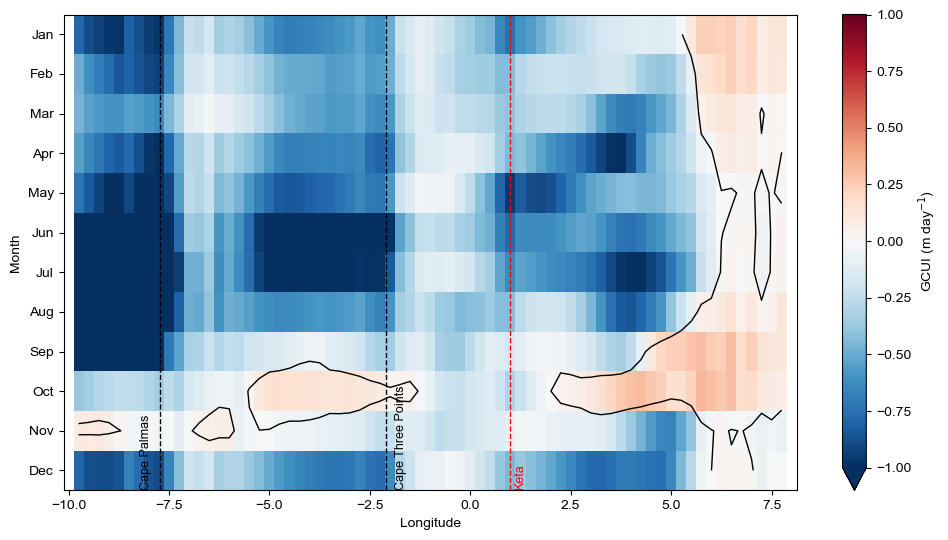

In [9]:
def plot_gcui_hovmoller(ds_master, fontsize=10):

    # 1. Spatial average over the coastal band
    coastal_ocn = ds_master.sel(latitude=slice(4.0, 6.0)).mean(dim='latitude')
    
    # 2. Monthly Climatology
    climatology = coastal_ocn.groupby('valid_time.month').mean()
    
    # Convert to m/day for consistency with your ECUI plot
    gcui_mday = climatology['GCUI'] * 86400


    fig, ax = plt.subplots(
        figsize=(10,5.5)
    )


    im = gcui_mday.plot(
        ax=ax,
        x="longitude",
        y="month",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        add_colorbar=True,
        add_labels=False,
        cbar_kwargs={
            "label":"GCUI (m day$^{-1}$)"
        }
    )
    
    ax.set_title("")


    # Zero line
    ax.contour(
        gcui_mday.longitude,
        gcui_mday.month,
        gcui_mday,
        levels=[0],
        colors="black",
        linewidths=1
    )


    # Important locations
    locations = [
        (-7.73, "Cape Palmas", "black", -0.35),
        (-2.09, "Cape Three Points", "black", 0.35),
        (0.99, "Keta", "red", 0.25)
    ]
    
    
    for lon, label, color, offset in locations:
    
        ax.axvline(
            lon,
            color=color,
            linestyle="--",
            linewidth=1
        )
    
        ax.text(
            lon + offset,          # shift text away from line
            12.5,                  # above the December row
            label,
            rotation=90,
            color=color,
            fontsize=9,
            ha="center",
            va="bottom",
            clip_on=False
        )


    ax.set_yticks(range(1,13))
    ax.set_yticklabels(
        ["Jan","Feb","Mar","Apr","May","Jun",
         "Jul","Aug","Sep","Oct","Nov","Dec"]
    )


    ax.invert_yaxis()


    ax.set_xlabel(
        "Longitude",
        fontsize=fontsize
    )

    ax.set_ylabel(
        "Month",
        fontsize=fontsize
    )


    ax.tick_params(
        labelsize=fontsize
    )


    plt.tight_layout()


    plt.savefig(
        "Figures/Figure_4_GCUI_Hovmoller_Climatology.jpg",
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()
plot_gcui_hovmoller(ds_final, fontsize=10)

## ECUI & GCUI Plot

In [10]:
def plot_ecui_gcui_hovmoller(ds_ecui, ds_gcui, fontsize=15):
    """
    Side-by-side Hovmöller plots for:
    (a) Transport-driven Upwelling (ECUI)
    (b) Geostrophic Upwelling (GCUI)
    """

    # -----------------------------
    # ECUI climatology
    # -----------------------------
    ecui_coastal = (
        ds_ecui
        .sel(latitude=slice(4.0, 6.5))
        .mean(dim='latitude')
    )

    ecui_clim = ecui_coastal.groupby('valid_time.month').mean()
    ecui_mday = ecui_clim['ECUI'] * 86400

    # -----------------------------
    # GCUI climatology
    # -----------------------------
    gcui_coastal = (
        ds_gcui
        .sel(latitude=slice(4.0, 6.0))
        .mean(dim='latitude')
    )

    gcui_clim = gcui_coastal.groupby('valid_time.month').mean()
    gcui_mday = gcui_clim['GCUI'] * 86400

    # -----------------------------
    # Figure
    # -----------------------------
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(16, 8),
        sharey=True
    )

    # -----------------------------
    # ECUI panel
    # -----------------------------
    im1 = ecui_mday.plot(
        ax=ax1,
        x='longitude',
        y='month',
        cmap='RdBu_r',
        add_colorbar=False
    )

    ax1.set_title(
        'Transport-driven Upwelling (ECUI)',
        fontweight='bold',
        fontsize=fontsize
    )

    ax1.set_xlabel('Longitude', fontsize=fontsize)
    ax1.set_ylabel('Month', fontsize=fontsize)

    ax1.set_yticks(range(1, 13))
    ax1.set_yticklabels(
        ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
        fontsize=fontsize
    )

    ax1.tick_params(axis='x', labelsize=fontsize)

    ax1.text(
        0.02, 0.95, '(a)',
        transform=ax1.transAxes,
        fontsize=fontsize,
        fontweight='bold',
        va='top',
        ha='left'
    )

    # Individual colorbar
    cbar1 = fig.colorbar(
        im1,
        ax=ax1,
        orientation='horizontal',
        pad=0.10
    )

    cbar1.set_label(
        'ECUI [m/day]',
        fontsize=fontsize
    )

    cbar1.ax.tick_params(labelsize=fontsize)

    # -----------------------------
    # GCUI panel
    # -----------------------------
    im2 = gcui_mday.plot(
        ax=ax2,
        x='longitude',
        y='month',
        cmap='RdBu_r',
        add_colorbar=False
    )

    ax2.set_title(
        'Geostrophic Upwelling (GCUI)',
        fontweight='bold',
        fontsize=fontsize
    )

    ax2.set_xlabel('Longitude', fontsize=fontsize)
    ax2.set_ylabel('')

    ax2.tick_params(axis='x', labelsize=fontsize)

    ax2.text(
        0.02, 0.95, '(b)',
        transform=ax2.transAxes,
        fontsize=fontsize,
        fontweight='bold',
        va='top',
        ha='left'
    )

    # Individual colorbar
    cbar2 = fig.colorbar(
        im2,
        ax=ax2,
        orientation='horizontal',
        pad=0.10
    )

    cbar2.set_label(
        'GCUI [m/day]',
        fontsize=fontsize
    )

    cbar2.ax.tick_params(labelsize=fontsize)

    # -----------------------------
    # Layout
    # -----------------------------
    plt.tight_layout()

    plt.savefig(
        'Figures/ECUI_GCUI_Hovmoller.png',
        dpi=300,
        bbox_inches='tight',
        pad_inches=0.04
    )

    plt.show()

## Figure 5 Plot

C:\Users\Annorion\anaconda3\Lib\site-packages\xarray\core\dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


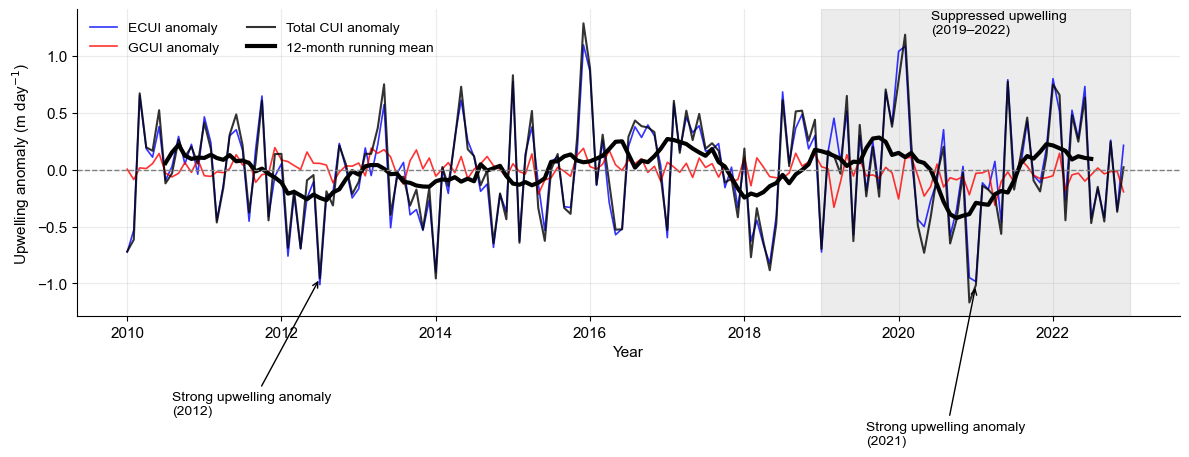

In [11]:

def plot_upwelling_timeseries(ds_master, fontsize=11):

    # ============================================================
    # 1. Extract Keta sector
    # ============================================================

    keta_box = ds_master.sel(
        longitude=slice(0.5, 1.5),
        latitude=slice(5.5, 6.0)
    ).mean(
        dim=["latitude", "longitude"]
    )


    # ============================================================
    # 2. Convert indices to m/day
    # ============================================================

    ecui = keta_box["ECUI"] * 86400
    gcui = keta_box["GCUI"] * 86400
    total = (keta_box["ECUI"] + keta_box["GCUI"]) * 86400


    # ============================================================
    # 3. Deseasonalize (monthly anomalies)
    # ============================================================

    ecui_anom = ecui.groupby(
        "valid_time.month"
    ).map(
        lambda x: x - x.mean("valid_time")
    )


    gcui_anom = gcui.groupby(
        "valid_time.month"
    ).map(
        lambda x: x - x.mean("valid_time")
    )


    total_anom = total.groupby(
        "valid_time.month"
    ).map(
        lambda x: x - x.mean("valid_time")
    )


    # ============================================================
    # 4. 12-month running mean of total CUI
    # ============================================================

    total_smooth = total_anom.rolling(
        valid_time=12,
        center=True
    ).mean()


    # ============================================================
    # 5. Plot
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(12,5)
    )


    ax.plot(
        ecui_anom.valid_time,
        ecui_anom,
        color="blue",
        linewidth=1.2,
        alpha=0.8,
        label="ECUI anomaly"
    )


    ax.plot(
        gcui_anom.valid_time,
        gcui_anom,
        color="red",
        linewidth=1.2,
        alpha=0.8,
        label="GCUI anomaly"
    )


    ax.plot(
        total_anom.valid_time,
        total_anom,
        color="black",
        linewidth=1.5,
        alpha=0.8,
        label="Total CUI anomaly"
    )


    # Running mean
    ax.plot(
        total_smooth.valid_time,
        total_smooth,
        color="black",
        linewidth=3,
        label="12-month running mean"
    )


    # ============================================================
    # 6. Zero anomaly baseline
    # ============================================================

    ax.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1
    )


    # ============================================================
    # 7. Highlight 2019-2022 suppression period
    # ============================================================

    ax.axvspan(
        pd.Timestamp("2019-01-01"),
        pd.Timestamp("2022-12-31"),
        color="gray",
        alpha=0.15
    )


    ax.text(
        pd.Timestamp("2020-06-01"),
        ax.get_ylim()[1]*0.85,
        "Suppressed upwelling\n(2019–2022)",
        ha="left",
        fontsize=fontsize-1
    )


    # ============================================================
    # 8. Annotate strong 2012  and 2021 event
    # ============================================================

    event_date = pd.Timestamp("2012-07-01")

    event_value = total_anom.sel(
        valid_time=event_date,
        method="nearest"
    )


    ax.annotate(
        "Strong upwelling anomaly\n(2012)",
        xy=(
            event_date,
            event_value
        ),
        xytext=(
            pd.Timestamp("2010-08-01"),
            event_value - 1.2
        ),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1
        ),
        fontsize=fontsize-1
    )

    event_2021 = total_anom.sel(valid_time="2021")

    imin = event_2021.argmin()
    
    event_date1 = pd.Timestamp(event_2021.valid_time[imin].values)
    event_value1 = event_2021.isel(valid_time=imin).values


    ax.annotate(
        "Strong upwelling anomaly\n(2021)",
        xy=(
            event_date1,
            event_value1
        ),
        xytext=(
            pd.Timestamp("2019-08-01"),
            event_value1 - 1.4
        ),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1
        ),
        fontsize=fontsize-1
    )


    # ============================================================
    # 9. Formatting
    # ============================================================

    ax.set_xlabel(
        "Year",
        fontsize=fontsize
    )


    ax.set_ylabel(
        "Upwelling anomaly (m day$^{-1}$)",
        fontsize=fontsize
    )


    ax.tick_params(
        axis="both",
        labelsize=fontsize
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend(
        fontsize=fontsize-1,
        frameon=False,
        ncol=2,
        loc="upper left"
    )


    # Remove top/right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


    plt.tight_layout()


    # ============================================================
    # 10. Save at publication resolution
    # ============================================================

    plt.savefig(
        "Figures/Figure_5_Keta_CUI_Anomalies_2010_2022.jpg",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.05
    )


    plt.show()



# Run
plot_upwelling_timeseries(
    ds_final,
    fontsize=11
)

## Adding Surface Variables (SST, SSH)

In [12]:
def add_surface_variables_refined(master_path, cmems_surface_path, output_path):
    # Load datasets
    ds_master = xr.open_dataset(master_path)
    ds_surf = xr.open_dataset(cmems_surface_path)

    # 1. Clean up the Master
    if 'time' in ds_master.coords:
        ds_master = ds_master.drop_vars('time')
    
    # RENAME zos to SSH in the Master dataset
    if 'zos' in ds_master.data_vars:
        ds_master = ds_master.rename({'zos': 'SSH'})

    # 2. Prepare Surface Data (SST and SSS)
    # Rename time to align with ERA5 'valid_time'
    ds_surf = ds_surf.rename({'time': 'valid_time', 'thetao': 'SST', 'so': 'SSS'})
    
    # Force 2D by selecting surface depth and dropping the dimension
    if 'depth' in ds_surf.coords:
        ds_surf = ds_surf.sel(depth=0.5, method='nearest').drop_vars('depth')

    # 3. Interpolate Surface data to Master Grid
    ds_surf_interp = ds_surf.interp(
        latitude=ds_master.latitude, 
        longitude=ds_master.longitude, 
        method='linear'
    )

    # 4. Merge all variables (Winds, Indices, SSH, SST, SSS)
    ds_combined = xr.merge([ds_master, ds_surf_interp])
    
    # 5. CALCULATE ANOMALIES (The "Deseasonalization")
    # This addresses Reviewer #5 by removing the predictable seasonal cycle
    climatology = ds_combined.groupby('valid_time.month').mean('valid_time')
    ds_combined_anom = ds_combined.groupby('valid_time.month') - climatology

    # Cleanup the helper coordinate 'month'
    if 'month' in ds_combined_anom.coords:
        ds_combined_anom = ds_combined_anom.drop_vars('month')

    # Save the anomaly dataset
    ds_combined_anom.to_netcdf(output_path)
    
    ds_master.close()
    ds_surf.close()
    
    print("Master Anomaly Dataset (2010-2022) created successfully.")
    return ds_combined_anom

# Execute
ds_final_anom = add_surface_variables_refined(
    "Data/Master_Upwelling_2010_2022.nc", 
    "Data/cmems_mod_glo_phy_my_0.083deg_P1M-m_1773145548147.nc", 
    "Data/Master_Anomalies_2010_2022.nc"
)

C:\Users\Annorion\AppData\Local\Temp\ipykernel_20632\1819866245.py:30: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_combined = xr.merge([ds_master, ds_surf_interp])


Master Anomaly Dataset (2010-2022) created successfully.


## Multivariate EOF Analysis

In [13]:
def run_multivariate_eof_robust(ds, variables=['ECUI', 'GCUI', 'SST', 'SSH']):
    # 1. Clean & Standardize
    ds_clean = ds[variables].dropna(dim='longitude', how='all').dropna(dim='latitude', how='all')
    ds_std = ds_clean / ds_clean.std(dim='valid_time')
    
    # 2. Area Weighting
    coslat = np.cos(np.deg2rad(ds_std.latitude))
    weights = np.sqrt(coslat)
    ds_weighted = ds_std * weights
    
    n_time = len(ds_weighted.valid_time)
    n_lat = len(ds_weighted.latitude)
    n_lon = len(ds_weighted.longitude)
    
    # 3. Flatten and Stack
    flattened_vars = []
    for v in variables:
        flat = ds_weighted[v].values.reshape(n_time, -1)
        flattened_vars.append(flat)
    
    combined_matrix = np.concatenate(flattened_vars, axis=1)
    
    # 4. Handle NaNs
    mask = ~np.isnan(combined_matrix).any(axis=0)
    ocean_only_matrix = combined_matrix[:, mask]
    
    # 5. Compute EOF
    solver = Eof(ocean_only_matrix)
    eof1_ocean = solver.eofs(neofs=1)
    pc1_values = solver.pcs(npcs=1, pcscaling=1)
    
    # FIX: Remove the 'neofs' argument for the standard solver
    var_frac = solver.varianceFraction()
    
    # 6. Reconstruct maps
    individual_eofs = {}
    eof1_full = np.full((1, combined_matrix.shape[1]), np.nan)
    eof1_full[0, mask] = eof1_ocean[0, :]
    
    for i, v in enumerate(variables):
        start = i * (n_lat * n_lon)
        end = (i + 1) * (n_lat * n_lon)
        eof_map = eof1_full[0, start:end].reshape(n_lat, n_lon)
        
        individual_eofs[v] = xr.DataArray(
            eof_map, 
            coords=[ds_std.latitude, ds_std.longitude], 
            dims=['latitude', 'longitude'],
            name=f"EOF1_{v}"
        )
        
    pc1 = xr.DataArray(pc1_values.flatten(), coords=[ds_weighted.valid_time], dims=['valid_time'])
    
    return individual_eofs, pc1, var_frac

# Execute
eofs_dict, pc1, var_frac = run_multivariate_eof_robust(ds_final_anom)
print(f"EOF1 explains {var_frac[0]*100:.2f}% of the variance.")

EOF1 explains 36.44% of the variance.


## Figure 6 Plot

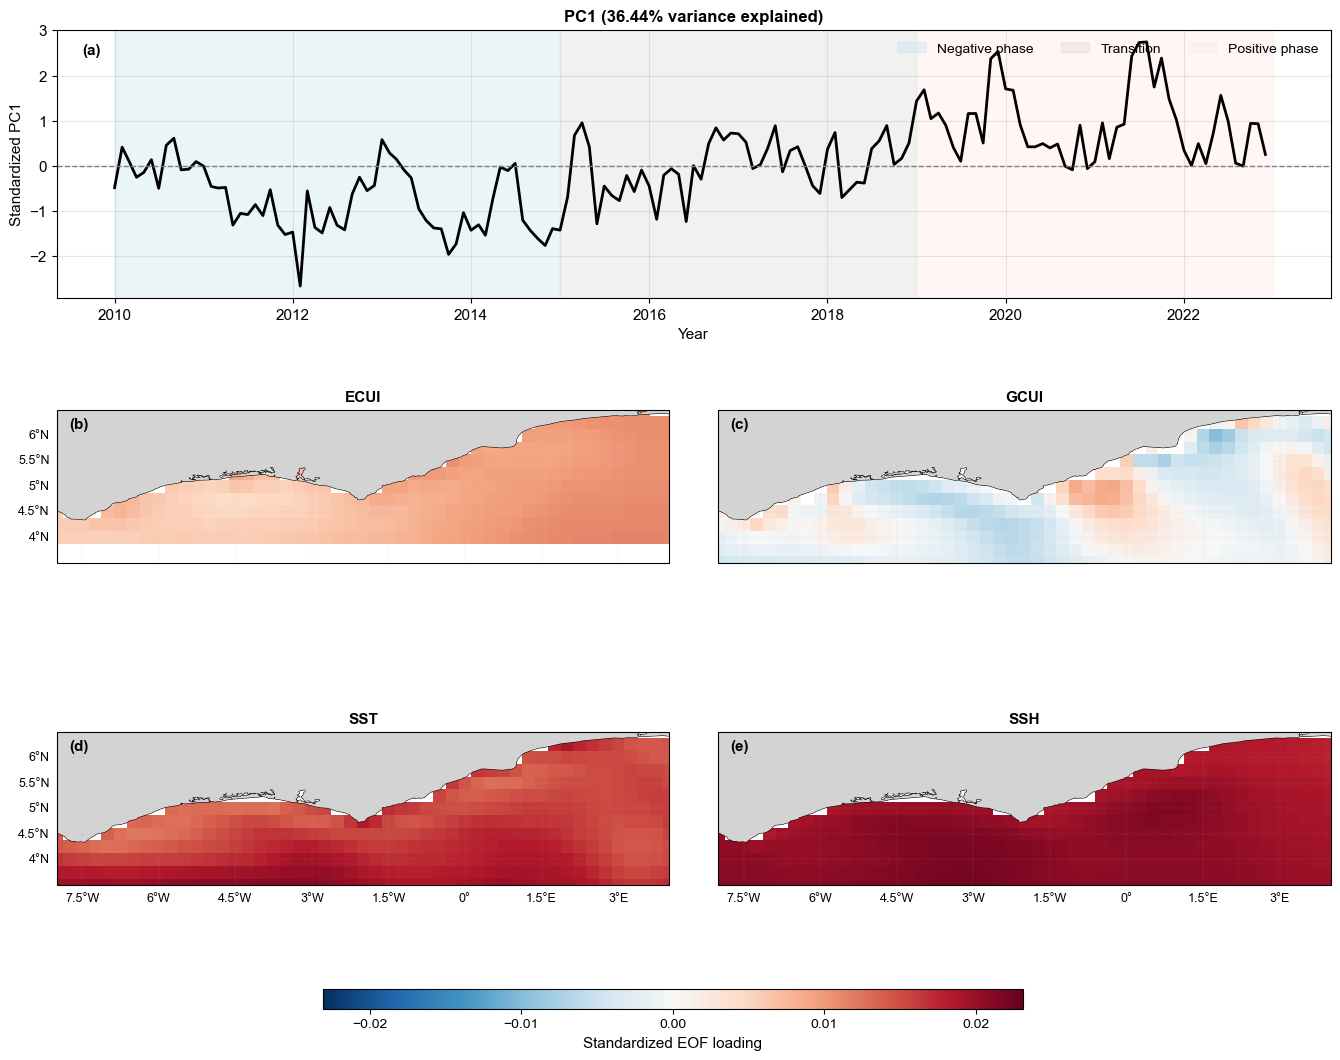

In [14]:



def plot_refined_meof(eofs_dict, pc1, var_frac, fontsize=11):

    # ============================================================
    # Determine common colour limits
    # ============================================================

    vmax = max(
        float(np.nanmax(np.abs(eofs_dict[var].values)))
        for var in eofs_dict
    )

    # ============================================================
    # Figure
    # ============================================================

    fig = plt.figure(figsize=(14, 11))

    # ============================================================
    # (a) Principal Component
    # ============================================================

    ax_pc = plt.subplot2grid(
        (3, 2),
        (0, 0),
        colspan=2
    )

    pc1.plot(
        ax=ax_pc,
        color="black",
        linewidth=2
    )

    variance = var_frac[0] * 100

    ax_pc.set_title(
        f"PC1 ({variance:.2f}% variance explained)",
        fontsize=fontsize + 1,
        fontweight="bold"
    )

    # ------------------------------------------------------------
    # Phase shading
    # ------------------------------------------------------------

    ax_pc.axvspan(
        pd.Timestamp("2010-01-01"),
        pd.Timestamp("2014-12-31"),
        color="lightblue",
        alpha=0.25,
        label="Negative phase"
    )

    ax_pc.axvspan(
        pd.Timestamp("2015-01-01"),
        pd.Timestamp("2018-12-31"),
        color="lightgray",
        alpha=0.30,
        label="Transition"
    )

    ax_pc.axvspan(
        pd.Timestamp("2019-01-01"),
        pd.Timestamp("2022-12-31"),
        color="mistyrose",
        alpha=0.30,
        label="Positive phase"
    )

    ax_pc.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1
    )

    ax_pc.set_ylabel(
        "Standardized PC1",
        fontsize=fontsize
    )

    ax_pc.set_xlabel(
        "Year",
        fontsize=fontsize
    )

    ax_pc.tick_params(
        labelsize=fontsize
    )

    ax_pc.grid(
        alpha=0.3
    )

    ax_pc.legend(
        frameon=False,
        fontsize=fontsize-1,
        ncol=3,
        loc="upper right"
    )

    ax_pc.text(
        0.02,
        0.95,
        "(a)",
        transform=ax_pc.transAxes,
        fontsize=fontsize,
        fontweight="bold",
        va="top"
    )

    # ============================================================
    # EOF Maps
    # ============================================================

    panel_labels = ["(b)", "(c)", "(d)", "(e)"]

    variables = list(eofs_dict.keys())

    axes = []

    for i, var in enumerate(variables):

        ax = plt.subplot2grid(
            (3, 2),
            (1 + i // 2, i % 2),
            projection=ccrs.PlateCarree()
        )

        axes.append(ax)

        eof = eofs_dict[var]

        im = eof.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),

            cmap="RdBu_r",

            vmin=-vmax,
            vmax=vmax,

            add_colorbar=False
        )

        # -----------------------------
        # Map Features
        # -----------------------------

        ax.add_feature(
            cfeature.LAND,
            facecolor="lightgray",
            zorder=2
        )

        ax.add_feature(
            cfeature.COASTLINE,
            linewidth=0.8
        )

        ax.add_feature(
            cfeature.BORDERS,
            linestyle=":",
            linewidth=0.5
        )

        ax.set_extent(
            [-8, 4, 3.5, 6.5]
        )

        gl = ax.gridlines(
            draw_labels=True,
            dms=False,
            linewidth=0.3,
            alpha=0.3,
            linestyle="--"
        )

        gl.top_labels = False
        gl.right_labels = False

        if i % 2 != 0:
            gl.left_labels = False

        if i < 2:
            gl.bottom_labels = False

        gl.xlabel_style = {
            "size": fontsize-2
        }

        gl.ylabel_style = {
            "size": fontsize-2
        }

        ax.set_title(
            var,
            fontsize=fontsize,
            fontweight="bold"
        )

        ax.text(
            0.02,
            0.95,
            panel_labels[i],
            transform=ax.transAxes,
            fontsize=fontsize,
            fontweight="bold",
            va="top"
        )

    # ============================================================
    # Shared Colorbar
    # ============================================================

    cbar_ax = fig.add_axes(
        [0.25, 0.06, 0.50, 0.018]
    )

    cbar = fig.colorbar(
        im,
        cax=cbar_ax,
        orientation="horizontal"
    )

    cbar.set_label(
        "Standardized EOF loading",
        fontsize=fontsize
    )

    cbar.ax.tick_params(
        labelsize=fontsize-1
    )

    # ============================================================
    # Layout
    # ============================================================

    plt.subplots_adjust(
        left=0.06,
        right=0.97,
        top=0.95,
        bottom=0.12,
        hspace=0.20,
        wspace=0.08
    )

    # ============================================================
    # Save
    # ============================================================

    plt.savefig(
        "Figures/Figure_6_mEOF1_Coupled_System.jpg",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.05
    )

    plt.show()


# ============================================================
# Run
# ============================================================

plot_refined_meof(
    eofs_dict,
    pc1,
    var_frac,
    fontsize=11
)

## EOF Loadings by Sector

In [15]:
def print_eof_loadings_by_sector(eofs_dict):
    # Define the sectors (Longitudes)
    sectors = {
        "Western Sector (Palmas/Three Points)": slice(-8, -2),
        "Keta/Central-Eastern Sector": slice(0.5, 1.5)
    }
    
    print("--- EOF1 LOADING ANALYSIS ---")
    for sector_name, lon_slice in sectors.items():
        print(f"\n{sector_name}:")
        for var_name, eof_map in eofs_dict.items():
            # Select the sector and take the spatial mean of the loading
            mean_loading = eof_map.sel(longitude=lon_slice).mean().values
            print(f"  * {var_name:4}: {mean_loading:.6f}")

# Run the analysis
print_eof_loadings_by_sector(eofs_dict)

--- EOF1 LOADING ANALYSIS ---

Western Sector (Palmas/Three Points):
  * ECUI: 0.005987
  * GCUI: -0.002958
  * SST : 0.018820
  * SSH : 0.021605

Keta/Central-Eastern Sector:
  * ECUI: 0.009728
  * GCUI: -0.001572
  * SST : 0.018732
  * SSH : 0.020684


## Bretherton Analysis

In [16]:


def run_bretherton_analysis(ds_anom, lon_range=[0.5, 1.5], lat_range=[5.0, 6.0], max_lag=6):
    # 1. Spatial Averaging for the Keta Sector
    keta = ds_anom.sel(longitude=slice(*lon_range), latitude=slice(*lat_range)).mean(dim=['latitude', 'longitude'])
    
    # Extract Time Series
    time_series = {
        'ECUI': keta.ECUI.values,
        'GCUI': keta.GCUI.values,
        'SST':  keta.SST.values
    }

    lags = np.arange(-max_lag, max_lag + 1)
    # Added 'SST' to results to store its autocorrelation
    results = {'ECUI': {'r': [], 'p': []}, 'GCUI': {'r': [], 'p': []}, 'SST': {}}

    # 2. Bretherton Significance Calculation (N_eff)
    N = len(keta.valid_time)
    
    # Calculate SST Autocorrelation once
    r1_sst = np.corrcoef(time_series['SST'][:-1], time_series['SST'][1:])[0, 1]
    results['SST']['r1'] = r1_sst

    for var in ['ECUI', 'GCUI']:
        # Get Lag-1 Autocorrelation for the driver
        r1_var = np.corrcoef(time_series[var][:-1], time_series[var][1:])[0, 1]
        results[var]['r1'] = r1_var
        
        # The Bretherton Formula
        n_eff = N * (1 - r1_var * r1_sst) / (1 + r1_var * r1_sst)
        results[var]['n_eff'] = n_eff

        for lag in lags:
            x = time_series[var]
            y = time_series['SST']
            
            if lag < 0: 
                c = np.corrcoef(x[-lag:], y[:lag])[0, 1]
            elif lag > 0: 
                c = np.corrcoef(x[:-lag], y[lag:])[0, 1]
            else: 
                c = np.corrcoef(x, y)[0, 1]
            
            t_stat = c * np.sqrt((n_eff - 2) / (1 - c**2))
            p = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=n_eff - 2))
            
            results[var]['r'].append(c)
            results[var]['p'].append(p)

    return lags, results

# --- Run the Analysis ---
lags, corr_data = run_bretherton_analysis(ds_final_anom)

In [17]:
lags

array([-6, -5, -4, -3, -2, -1,  0,  1,  2,  3,  4,  5,  6])

## Figure 7 Plot


===== Figure 7 Statistics =====
Effective degrees of freedom : 130.7
95% significance threshold   : ±0.1714
ECUI correlation at lag 0    : 0.4707
GCUI correlation at lag 0    : 0.0528
ECUI peak lag               : 0
GCUI peak lag               : -1


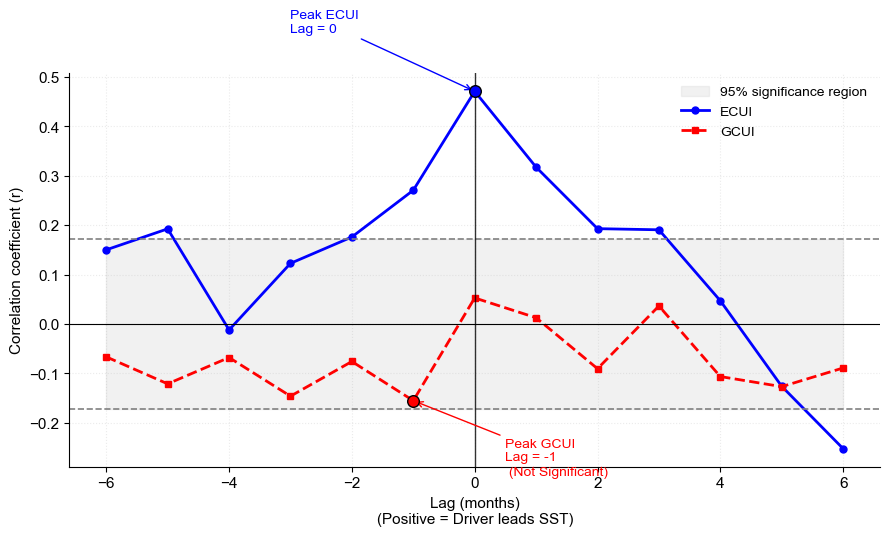

In [18]:


def plot_synergy_lags(lags, data, fontsize=11):

    fig, ax = plt.subplots(figsize=(9, 5.5))

    # ============================================================
    # Effective degrees of freedom (Bretherton et al., 1999)
    # ============================================================

    avg_neff = (
        data["ECUI"]["n_eff"] +
        data["GCUI"]["n_eff"]
    ) / 2

    conf_limit = 1.96 / np.sqrt(avg_neff)

    # ============================================================
    # Significance band
    # ============================================================

    ax.fill_between(
        lags,
        -conf_limit,
        conf_limit,
        color="lightgray",
        alpha=0.30,
        label="95% significance region"
    )

    # ============================================================
    # ECUI
    # ============================================================

    ax.plot(
        lags,
        data["ECUI"]["r"],
        color="blue",
        linestyle="-",
        marker="o",
        markersize=5,
        linewidth=2,
        label="ECUI"
    )

    # ============================================================
    # GCUI
    # ============================================================

    ax.plot(
        lags,
        data["GCUI"]["r"],
        color="red",
        linestyle="--",
        marker="s",
        markersize=5,
        linewidth=2,
        label="GCUI"
    )

    # ============================================================
    # Peak correlations
    # ============================================================

    ecui_peak = np.argmax(np.abs(data["ECUI"]["r"]))
    gcui_peak = np.argmax(np.abs(data["GCUI"]["r"]))

    # ECUI peak marker

    ax.scatter(
        lags[ecui_peak],
        data["ECUI"]["r"][ecui_peak],
        s=70,
        color="blue",
        edgecolor="black",
        zorder=5
    )

    # GCUI peak marker

    ax.scatter(
        lags[gcui_peak],
        data["GCUI"]["r"][gcui_peak],
        s=70,
        color="red",
        edgecolor="black",
        zorder=5
    )

    # ============================================================
    # Peak annotations
    # ============================================================

    ax.annotate(
        f"Peak ECUI\nLag = {lags[ecui_peak]}",
        xy=(
            lags[ecui_peak],
            data["ECUI"]["r"][ecui_peak]
        ),
        xytext=(
            lags[ecui_peak]-3,
            data["ECUI"]["r"][ecui_peak]+0.12
        ),
        fontsize=fontsize-1,
        color="blue",
        arrowprops=dict(
            arrowstyle="->",
            color="blue",
            lw=1
        )
    )

    ax.annotate(
        f"Peak GCUI\nLag = {lags[gcui_peak]}\n (Not Significant)",
        xy=(
            lags[gcui_peak],
            data["GCUI"]["r"][gcui_peak]
        ),
        xytext=(
            lags[gcui_peak]+1.5,
            data["GCUI"]["r"][gcui_peak]-0.15
        ),
        fontsize=fontsize-1,
        color="red",
        arrowprops=dict(
            arrowstyle="->",
            color="red",
            lw=1
        )
    )

    # ============================================================
    # Reference lines
    # ============================================================

    ax.axhline(
        conf_limit,
        color="gray",
        linestyle="--",
        linewidth=1.2
    )

    ax.axhline(
        -conf_limit,
        color="gray",
        linestyle="--",
        linewidth=1.2
    )

    ax.axhline(
        0,
        color="black",
        linewidth=0.8
    )

    ax.axvline(
        0,
        color="black",
        linewidth=1,
        alpha=0.8
    )

    # ============================================================
    # Axes
    # ============================================================

    ax.set_xlabel(
        "Lag (months)\n(Positive = Driver leads SST)",
        fontsize=fontsize
    )

    ax.set_ylabel(
        "Correlation coefficient (r)",
        fontsize=fontsize
    )

    ax.set_xticks(
        np.arange(
            np.min(lags),
            np.max(lags)+1,
            2
        )
    )

    ax.tick_params(
        axis="both",
        labelsize=fontsize
    )

    # ============================================================
    # Grid
    # ============================================================

    ax.grid(
        alpha=0.25,
        linestyle=":"
    )

    # ============================================================
    # Legend
    # ============================================================

    ax.legend(
        frameon=False,
        fontsize=fontsize-1,
        loc="upper right"
    )

    # ============================================================
    # Clean journal style
    # ============================================================

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    # ============================================================
    # Save
    # ============================================================

    plt.savefig(
        "Figures/Figure_7_Lagged_Correlation_Keta.jpg",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.05
    )

    plt.show()


# ============================================================
# Print useful statistics
# ============================================================

lag0 = list(lags).index(0)

avg_neff = (
    corr_data["ECUI"]["n_eff"] +
    corr_data["GCUI"]["n_eff"]
) / 2

sig_threshold = 1.96 / np.sqrt(avg_neff)

print("\n===== Figure 7 Statistics =====")
print(f"Effective degrees of freedom : {avg_neff:.1f}")
print(f"95% significance threshold   : ±{sig_threshold:.4f}")
print(f"ECUI correlation at lag 0    : {corr_data['ECUI']['r'][lag0]:.4f}")
print(f"GCUI correlation at lag 0    : {corr_data['GCUI']['r'][lag0]:.4f}")
print(f"ECUI peak lag               : {lags[np.argmax(np.abs(corr_data['ECUI']['r']))]}")
print(f"GCUI peak lag               : {lags[np.argmax(np.abs(corr_data['GCUI']['r']))]}")

# ============================================================
# Plot
# ============================================================

plot_synergy_lags(
    lags,
    corr_data,
    fontsize=11
)